# Enterprise Data Architecture & Reconciliation

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

## Your Mission
You must architect a Python pipeline to extract, clean, merge, and visualize this data.

**Requirements for Passing:**
1. **Advanced SQL:** Extract only "Active" users from the database using the most recent `updated_at` timestamp.
2. **String Manipulation (Regex):** Extract the Date, User ID, Product ID, and Euro Value from the raw text logs. Filter out rows labeled "ERROR".
3. **Temporal Joins:** Join the transactions to the exchange rate table based on the exact day. You must forward-fill the weekend exchange rates so transactions don't drop out.
4. **Efficiency:** Your code must run on all 100,000 rows in under 2 minutes. No `for` loops allowed in Pandas.
5. **Dashboard:** Build visualizations showing Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [3]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to 'enterprise_database.db'
# 2. Write a SQL query (using Window Functions or Subqueries) to get the most
#    recent status for each user.
# 3. Only keep users whose latest status is 'Active'.
# 4. Load the result into a Pandas DataFrame called 'df_active_users'.

conn = sqlite3.connect("enterprise_database.db")

query = """
SELECT user_id, name, status, updated_at
FROM (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)
WHERE rn = 1
  AND status = 'Active';
"""

df_active_users = pd.read_sql_query(query, conn)

print("Latest Active Users:")
print(df_active_users)

print("\nNumber of Active Users:", len(df_active_users))

Latest Active Users:
       user_id          name  status           updated_at
0      U-00001  User_U-00001  Active  2023-01-28 14:00:00
1      U-00003  User_U-00003  Active  2023-01-22 14:00:00
2      U-00005  User_U-00005  Active  2023-01-17 14:00:00
3      U-00006  User_U-00006  Active  2023-01-05 14:00:00
4      U-00007  User_U-00007  Active  2023-01-27 14:00:00
...        ...           ...     ...                  ...
14178  U-24989  User_U-24989  Active  2023-01-22 14:00:00
14179  U-24991  User_U-24991  Active  2023-01-08 14:00:00
14180  U-24992  User_U-24992  Active  2023-01-16 14:00:00
14181  U-24995  User_U-24995  Active  2023-01-06 14:00:00
14182  U-24996  User_U-24996  Active  2023-01-20 14:00:00

[14183 rows x 4 columns]

Number of Active Users: 14183


In [5]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# 1. Load 'server_logs.txt' into a DataFrame.
# 2. Drop any rows where the log contains the word "ERROR".
# 3. Use Pandas string methods (.str.extract()) or Python Regex to pull the
#    Date, User ID, Product ID, and Euro Value out of the raw text string.
# 4. Save this cleaned data to a new DataFrame called 'extracted_data'.

logs_df = pd.read_csv("server_logs.txt")

print("Original data:")
print(logs_df.head())
print("\nOriginal shape:", logs_df.shape)

clean_logs = logs_df[
    ~logs_df["Raw_Server_Log"].str.contains("ERROR", case=False, na=False)
].copy()

print("\nAfter removing ERROR rows:")
print(clean_logs.shape)

pattern = (
    r'\[(\d{4}-\d{2}-\d{2}).*?'
    r'"u":"(U-\d+)".*?'
    r'"item_code":"(PRD-\d+)".*?'
    r'"eur_val":([0-9]+(?:\.[0-9]+)?)'
)

extracted_data = clean_logs["Raw_Server_Log"].str.extract(
    pattern,
    expand=True
)

extracted_data.columns = [
    "date",
    "user_id",
    "product_id",
    "eur_value"
]

extracted_data["date"] = pd.to_datetime(extracted_data["date"])
extracted_data["eur_value"] = pd.to_numeric(
    extracted_data["eur_value"]
)

print("\nExtracted Data:")
print(extracted_data.head())

print("\nExtracted Data Shape:")
print(extracted_data.shape)

print("\nMissing Values:")
print(extracted_data.isnull().sum())

Original data:
                                      Raw_Server_Log
0  [2023-03-15 00:00:00] INFO: Transaction proces...
1  [2023-09-09 00:00:00] ERROR: Transaction proce...
2  [2023-05-09 00:00:00] INFO: Transaction proces...
3  [2023-10-21 00:00:00] INFO: Transaction proces...
4  [2023-01-10 00:00:00] INFO: Transaction proces...

Original shape: (100000, 1)

After removing ERROR rows:
(94902, 1)

Extracted Data:
        date  user_id product_id  eur_value
0 2023-03-15  U-19484    PRD-874    3404.44
2 2023-05-09  U-18932    PRD-905    3406.21
3 2023-10-21  U-15882    PRD-284     164.08
4 2023-01-10  U-22781    PRD-665      26.80
5 2023-05-23  U-13348    PRD-589    4964.77

Extracted Data Shape:
(94902, 4)

Missing Values:
date          0
user_id       0
product_id    0
eur_value     0
dtype: int64


In [ ]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# 1. Load 'daily_exchange_rates.csv' into a DataFrame.
# 2. Handle the missing weekend data using a method like .fillna(method='ffill')
#    so Friday's rate rolls over to Saturday and Sunday.
# 3. Merge your cleaned logs with the exchange rates by Date.
# 4. Merge that result with your active SQL users by User ID.
# 5. Calculate a new column called 'USD_Revenue' (Euro Value * Exchange Rate).
# 6. Save the final merged table as 'df_final'.
exchange_rates = pd.read_csv("daily_exchange_rates.csv")

print("--- Exchange Rates ---")
print(exchange_rates.head())

print("\nExchange Rates Shape:")
print(exchange_rates.shape)

print("\nExchange Rate Columns:")
print(exchange_rates.columns)

exchange_rates = exchange_rates.rename(columns={
    "Date": "date",
    "EUR_to_USD": "exchange_rate"
})

exchange_rates["date"] = pd.to_datetime(exchange_rates["date"])

exchange_rates = exchange_rates.sort_values("date")

exchange_rates["exchange_rate"] = exchange_rates["exchange_rate"].ffill()

print("\n--- Exchange Rates After Forward Fill ---")
print(exchange_rates.head(10))

extracted_data["date"] = pd.to_datetime(extracted_data["date"])

merged_finance = pd.merge(
    extracted_data,
    exchange_rates,
    on="date",
    how="left"
)

print("\n--- Transactions + Exchange Rates ---")
print(merged_finance.head())

print("\nMerged Shape:")
print(merged_finance.shape)

df_final = pd.merge(
    merged_finance,
    df_active_users,
    on="user_id",
    how="inner"
)

print("\n--- Final Merged DataFrame ---")
print(df_final.head())

print("\nFinal Shape:")
print(df_final.shape)

df_final["USD_Revenue"] = (
    df_final["eur_value"] * df_final["exchange_rate"]
)

print("\n--- Final Data with USD Revenue ---")
print(df_final.head())

print("\nFinal Columns:")
print(df_final.columns.tolist())

print("\nMissing Values:")
print(df_final.isnull().sum())

--- Exchange Rates ---
         Date  EUR_to_USD
0  2023-01-01    1.124836
1  2023-01-02    1.093087
2  2023-01-03    1.132384
3  2023-01-04    1.176151
4  2023-01-05    1.088292

Exchange Rates Shape:
(365, 2)

Exchange Rate Columns:
Index(['Date', 'EUR_to_USD'], dtype='str')

--- Exchange Rates After Forward Fill ---
        date  exchange_rate
0 2023-01-01       1.124836
1 2023-01-02       1.093087
2 2023-01-03       1.132384
3 2023-01-04       1.176151
4 2023-01-05       1.088292
5 2023-01-06       1.088292
6 2023-01-07       1.088292
7 2023-01-08       1.138372
8 2023-01-09       1.076526
9 2023-01-10       1.127128

--- Transactions + Exchange Rates ---
        date  user_id product_id  eur_value  exchange_rate
0 2023-03-15  U-19484    PRD-874    3404.44       1.178232
1 2023-05-09  U-18932    PRD-905    3406.21       1.104983
2 2023-10-21  U-15882    PRD-284     164.08       1.075350
3 2023-01-10  U-22781    PRD-665      26.80       1.127128
4 2023-05-23  U-13348    PRD-589    4

--- Total USD Revenue by Month ---
      month   USD_Revenue
0   2023-01  1.284176e+07
1   2023-02  1.143613e+07
2   2023-03  1.234893e+07
3   2023-04  1.201538e+07
4   2023-05  1.233364e+07
5   2023-06  1.208436e+07
6   2023-07  1.244416e+07
7   2023-08  1.281273e+07
8   2023-09  1.222895e+07
9   2023-10  1.250133e+07
10  2023-11  1.258822e+07
11  2023-12  1.263902e+07

--- Top 5 Most Valuable Customers ---
       user_id          name   USD_Revenue
3613   U-06582  User_U-06582  40050.988262
12937  U-23313  User_U-23313  39555.806629
2078   U-03805  User_U-03805  39529.945085
11066  U-20018  User_U-20018  38649.965242
3553   U-06489  User_U-06489  38629.142146


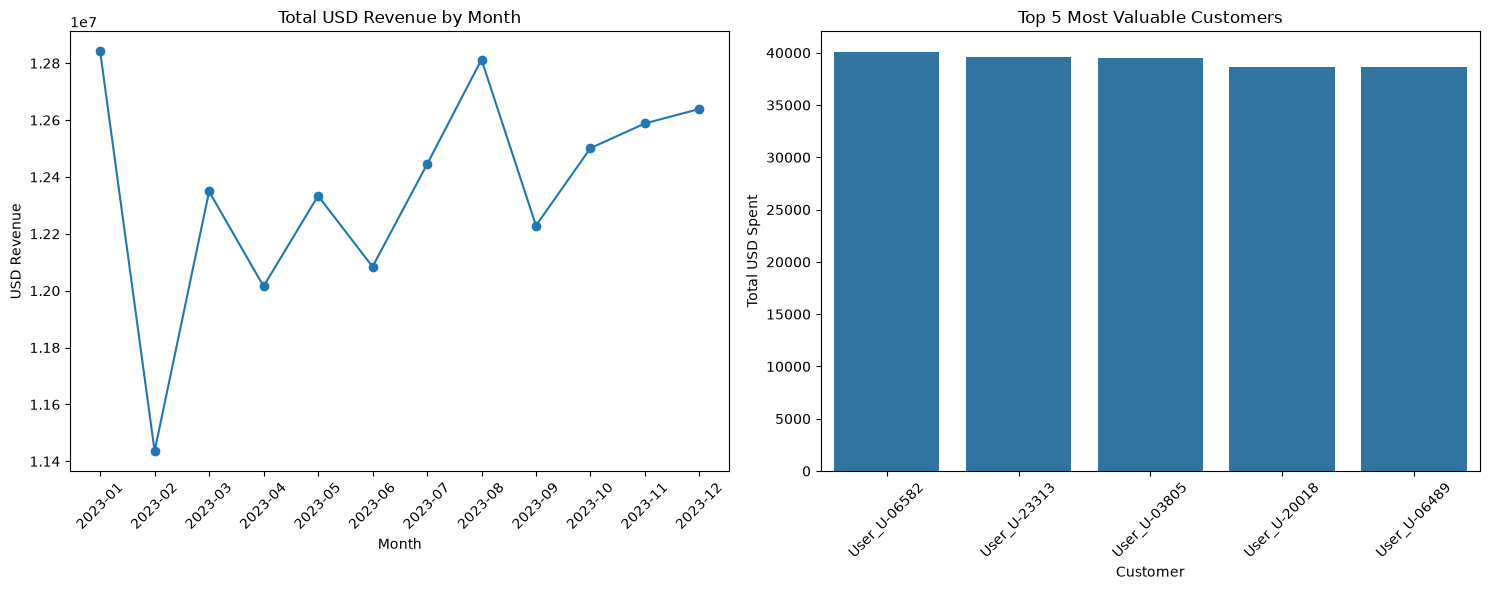

In [7]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

# 1. Group the data in 'df_final' to calculate Total USD Revenue by Month.
# 2. Group the data to find the Top 5 Most Valuable Customers by Total USD spent.
# 3. Use Matplotlib or Seaborn to generate two charts side-by-side:
#    - Chart 1: A Line Chart or Bar Chart showing Revenue by Month.
#    - Chart 2: A Bar Chart showing the Top 5 Customers.
# 4. Ensure your charts have titles, clean axes, and are easy to read.

df_final["month"] = df_final["date"].dt.to_period("M").astype(str)

monthly_revenue = (
    df_final.groupby("month")["USD_Revenue"]
    .sum()
    .reset_index()
)

print("--- Total USD Revenue by Month ---")
print(monthly_revenue)

top5_customers = (
    df_final.groupby(["user_id", "name"])["USD_Revenue"]
    .sum()
    .reset_index()
    .sort_values("USD_Revenue", ascending=False)
    .head(5)
)

print("\n--- Top 5 Most Valuable Customers ---")
print(top5_customers)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(
    monthly_revenue["month"],
    monthly_revenue["USD_Revenue"],
    marker="o"
)

axes[0].set_title("Total USD Revenue by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("USD Revenue")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=top5_customers,
    x="name",
    y="USD_Revenue",
    ax=axes[1]
)

axes[1].set_title("Top 5 Most Valuable Customers")
axes[1].set_xlabel("Customer")
axes[1].set_ylabel("Total USD Spent")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()